# Krachtactuator Ontwerpopdracht

In de eerste 4 weken van het vak DEF-D hebben jullie simulaties gedaan van verschillende opstellingen in de electrostatica. Jullie zijn in week 3.6 bij het vak electromagnetisme doorgegaan met de magnetostatica. Deze opdracht gaat in op het simuleren van deze magnetostatica.

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

De opdracht bestaat uit de volgende sub-onderdelen:
1) Afleiden van een analytische vergelijking
2) Criteria opstellen
3) Simuleren om de grenzen van jullie ontwerpparameters te bepalen
4) Numeriek berekenen van het magneetveld
5) Numeriek berekenen van het magneetveld van een solenoide
6) Bereken krachtrespons van een kracht actuator
7) Beoordeling van de criteria

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.9 beoordeeld en herkansingen zijn in week 3.10, zie de studiehandleiding voor details.

Technische Instructies:
- Download de zip map die op brightspace staat en unzip deze.
- Creëer een nieuwe branch in je Github repo voor deze opdracht.
- Plaats de geunzipte map op de juiste plek in jouw branch, zoals in de handleiding op brightspace staat.
- Nodig je teamgenoot uit als collaborateur op jouw repo.

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Probeer de voorbeeld code te begrijpen.
- Op een aantal plekken zijn voorbeelden gegeven of bepaalde numerieke methodes sterk versimpeld. Deze code kunnen reprocuderen is niet een leerdoel van dit vak en zal later in de opleiding voorkomen. Denk hierbij aan het integreren en differentieeren, probeer deze dingen wel te begrijpen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# DEF-D opdracht 2: Ontwerp een solenoïdale krachtactuator


<img align="right" style="margin-left:15px" src="figures\solenoidactuator.png" width="600">


In deze ontwerpopdracht ga je een krachtactuator ontwerpen gebaseerd op een solenoïde en een permanente magneet. Deze lineaire krachtactuatoren worden gebruikt om bijvoorbeeld kleppen en afsluiters elektronisch te bedienen. Ook komen ze in vele huidshoudelijke apparaten voor. Hiernaast zie je een plaatje van een krachtactuator van de buitenkant en van de doorsnede. De krachtactuator bestaat uit een solenoïde (spoel), dat is een spiraalvormige stroomkring waar een stroom doorheen loopt. Zoals je weet kan je met een solenoide een redelijk homogeen veld maken als de solenoide lang en smal is. In de solenoïde  zit een cilinder,een zogeheten plunjer, die kan schuiven in de solenoïde. De plunjer is verbonden met het object dat je wilt bewegen. De plunjer kan gemaakt zijn van een magnetisch materiaal met een hoge magnetische permeabiliteit of van een permanente magneet. In dit voorbeeld kiezen we voor een plunjer van magnetiseerbaar materiaal.

Voor het ontwerpen van de actuator gaan we eerst de kracht van de actuator uitrekenen met behulp van analytische theorie. We nemen eerst aan dat de solenoïde ideaal is en leiden daarvoor een analytische vergelijking af. Nadat we een eerste ontwerp hebben gemaakt gebaseerd op de analytische oplossing gaan we simuleren hoe goed onze krachtactuator echt werkt en of we het ontwerp nog kunnen verbeteren. Daar gaan we!

## Deel 1: afleiden van een analytische vergelijking

Hier onder ze je een detaildoorsnede van de solenoïde. De solenoïde heeft een lengte $L_s$, $N$ wikkelingen, een straal $r_s$ en er loopt een constante stroom $I$ door de draad. De plunjer is een afstand $z_p$ in de solenoide geschoven en moet over een zo groot mogelijke afstand een kracht uitoefenen. Een ideale solenoïde heeft binnenin een constant veld dat overal langs de as is gericht, buiten de solenoïde is het veld nul. Daarnaast nemen we aan dat het magnetisch materiaal homogeen en lineair is en een relatieve permeabiliteit $\mu_r$ heeft.

<center>
<img src="figures\solenoidactuatorgraph.png" width="1000">
</center>

**Opdracht 1**

a. Pas de wet van Ampère toe voor het $\mathbf{H}$-veld met gebruik van contour $\cal C$.\
b. Leidt een vergelijking af voor het $\mathbf{B}$-veld als functie van $z_p$.\
c. Voldoet jouw afleiding aan de randvoorwaarden voor het H en B veld?

**Afleiding Opdracht 1**

Zie bijgevoegde afbeelding `afleiding_opdracht1.png`. 
Kort samengevat: We passen Ampère toe langs een rechthoekige contour die deels door de ijzeren plunjer en deels door de lucht gaat. Het H-veld in de plunjer is B/(μ_r μ_0) en in de lucht B/μ_0. De stroom omsloten is N I. Uiteindelijk vinden we B = μ_0 μ_r N I / (L_s + (μ_r - 1) z_p). De randvoorwaarden kloppen want B⊥ is continu en H∥ is continu als er geen vrije stromen zijn.

Het randveld van de solenoïde zal de plunjer de solenoïde intrekken. Echter, het berekenen van de randvelden is een hele klus, we zullen dit later doen. We gebruiken hier een aanpak soortgelijk aan die voor een dielektricum in een condensator. Allereerst berekenen we de totale energie van het systeem met behulp van $W = \frac{1}{2} \int_{\cal V} \mathbf{H} \cdot \mathbf{B} \, d\tau $. Daarna bepalen we de kracht op de plunjer door de afgeleide van de energie naar de positie te nemen. We nemen aan dat de plunjer dezelfde straal heeft als de solenoide, $r_s$. 

**Opdracht 2**

Bereken de totale hoeveelheid energie in de solenoïde als functie van $z_d$ door de veldenergie over het volume van de solenoïde te integreren met behulp van bovenstaande vergelijking.

**Afleiding Opdracht 2**

Zie `afleiding_opdracht2.png`. 
Energie W = 1/2 * B^2/(μ_0 μ_r) * volume plunjer + 1/2 * B^2/μ_0 * volume lucht in de solenoide. 
Na invullen van B uit opdracht 1 en integreren over de lengte (van -L_s/2 tot z_p voor plunjer, en van z_p tot L_s/2 voor lucht) krijgen we een nogal lelijke uitdrukking. Uiteindelijk is de energie afhankelijk van z_p.

Zoals je wellicht ziet uit je afleiding is de energie van de plunjer groter als de plunjer er geheel uit is en kleiner als de plunjer er geheel in is. De afgeleide van de energie naar de positie $z_p$ geeft dan ook een kracht die de plunjer naar buiten beweegt. Dit is fysisch niet wat er gebeurd. Wat we in de afleiding niet hebben meegenomen is de energie die het kost om de stroom te laten stromen. Het veranderende magneetveld veroorzaakt door het naar binnen bewegen van de magneet (wet van Faraday) geeft een stroom tegengesteld aan de aangelegde stroom, de stroombron moet dan dus meer vermogen gaan leveren om de stroom op gang te houden. Als we dit effect wel meenemen blijkt dat de grootte van de kracht gelijk is, maar dat deze dan de plunjer de solenoide intrekt. We gaan hier niet verder op in.


**Opdracht 3**

Bereken de kracht van de spoel op de plunjer.

**Afleiding Opdracht 3**

Zie `afleiding_opdracht3.png`. 
De kracht is F = -dW/dz_p (met het minteken omdat de energie afneemt als de plunjer naar binnen gaat). 
Na differentiëren en vereenvoudigen (voor μ_r >> 1) vinden we F ≈ - (μ_0 μ_r N^2 I^2 π r_s^2) / (2 L_s^2). Dit is constant onafhankelijk van z_p voor een ideale solenoide.

## Deel 2: Criteria opstellen

Jullie gaan nu een magnetische kracht actuator ontwerpen hiervoor gaan jullie nu een ontwerpcyclus doorlopen.

**Opdracht 4**

a. Bedenk en schets vijf toepassingen van een kracht actuator.\
b. Kies uit deze toepassingen minimaal 2 toepassingen voor een kracht actuator om verder mee door te rekenen.

**Schetsen toepassingen**

Zie `schetsen_toepassingen.jpg`. 
1. Deurklink/elektrisch slot (trekt grendel in)
2. Klep in een koffiezetapparaat (opent watertoevoer)
3. Relais in een auto (schakelt hoge stroom)
4. Trilmotor in een telefoon (excentrische massa)
5. Klep in een medisch beademingsapparaat

Wij kiezen voor de toepassingen: (1) deuractuator (zoals in de opdracht) en (2) een klep voor een koffiezetapparaat.

**Opdracht 5**

We gaan nu verder kijken naar de criteria van jullie kracht actuatoren. Wij hebben alvast twee essentiele criteria vastgesteld zodat we hier later in de opdracht mee verder kunnen rekenen. Hieronder zijn 4 veelgebruikte stroombronnen benoemd die jullie gaan gebruiken voor een van de criteria.

| Spanningsbron             | Stroomsterkte | Voltage | draad dikte van de spoel |
|:--------------------------|:--------------|:--------|:-------------------------|
| Arduino uno digital pin   | 40 mA         | 5 V     | 0.05 mm                  |
| 9 Volt batterij           | 500 mA        | 9 V     | 0.1  mm                  |
| 40 Watt telefoon oplader | 2 A           | 20 V    | 0.2 mm                   |
| Een auto batterij         | 180 A         | 12 V    | 1.5 mm                   |


a. Kies een van de hierboven benoemde stroombronnen om te gebruiken in jullie ontwerp. \
b. Gebruik de methode uit het college 'schattend rekenen' om voor elke toepassing de minimale kracht die de actuator moet kunnen leveren voor jullie toepassing te bepalen.\
c. Denk na over wat de straal van jullie actuator mag zijn. \
d. Bedenk nog 1 ander criterium per toepassing.

**Uitwerking vraag 5**

Zie `uitwerking_vraag5.jpg`. 
a. Wij kiezen de 9V batterij (500 mA) voor beide toepassingen vanwege de veiligheid en beschikbaarheid.
b. Deuractuator: Deur weegt ongeveer 20 kg, maar we moeten alleen de grendel bewegen. Schatting: kracht 40 N (zoals gegeven). Koffiezetklep: waterdruk ~1 bar, oppervlak klepje ~1 cm^2 -> kracht ~10 N. Dus minimale kracht 10 N.
c. Straal van de actuator: voor de deur mag die best groot zijn, max 5 cm; voor koffiezetapparaat moet het klein zijn, max 1 cm.
d. Extra criteria: Deuractuator moet werken bij temperaturen van -10 tot 40°C; Koffiezetklep moet bestand zijn tegen kalkaanslag en vocht.

## Deel 3: Simuleren om de grenzen van jullie ontwerpparameters te bepalen

Jullie zullen nu simulaties gaan uitvoeren om de grenzen van jullie ontwerpparameters op te zoeken. Dit doen jullie voor jullie twee gekozen toepassingen en een deuractuator. Deze deuractuator moet een deur van het slot afhaalen door een kracht van 40 N uit te oefenen, gebruikt een 9 volt batterij als stroombron, de plunjer is gemaakt van ijzer en de straal van de actuator is 0.01 m.

**Opdracht 6**

Zet de relevante parameters in een Python script en maak een Python functie die met behulp van de wet van Ohm de maximale draadlengte uitrekent. Print de maximale draadlengte bij het uitvoeren van het script.

**Afleiding draadlengte**
We gebruiken de wet van Ohm: V = I * R, met R = ρ * L_draad / A, waarbij ρ de soortelijke weerstand van koper (1.68e-8 Ωm), A = π*(d/2)^2 de doorsnede van de draad. Dan L_max = V * A / (I * ρ).

In [2]:
# Opdracht 6: maximale draadlengte
def max_draadlengte(V, I, d_draad, rho=1.68e-8):
    A = np.pi * (d_draad/2)**2
    R_max = V / I
    L_max = R_max * A / rho
    return L_max

# Parameters voor deuractuator (9V batterij, draaddikte 0.1 mm)
V_bat = 9  # Volt
I_bat = 0.5  # A
d_draad = 0.1e-3  # m
L_max = max_draadlengte(V_bat, I_bat, d_draad)
print(f"Maximale draadlengte bij 9V batterij: {L_max:.2f} m")

Maximale draadlengte bij 9V batterij: 8.41 m


**Opdracht 7**

Leidt een vergelijking af voor het minimale aantal wikkelingen $N$ die je nodig hebt om het gewicht op te kunnen tillen. Voeg je afleiding als png toe aan je notebook.

**Afleiding opdracht 7**

Zie `afleiding_opdracht7.png`. 
Uit de krachtformule F = (μ_0 μ_r N^2 I^2 π r_s^2) / (2 L_s^2) (we laten het minteken weg voor de grootte). Oplossen naar N: N_min = sqrt( (2 F L_s^2) / (μ_0 μ_r I^2 π r_s^2) ). Voor de deuractuator met F=40 N, L_s=0.1 m, r_s=0.01 m, μ_r≈2000 (ijzer), I=0.5 A, geeft dit N_min ≈ 1600.

We gaan nu de ontwerpvrijheid verkennen. Gegeven de materiaalparameters en de eigenschappen van de stroombron kunnen we de verhouding tussen de lengte en de straal van de solenoide kiezen.

**Opdracht 8**

Schrijf een enkele Python functie die het minimum en maximum aantal wikkelingen uitrekent als functie van $L_s$, $r_s$, $r_d$ en $I$. De functie moet de volgende voorwaarden controleren
1) Het minimum aantal wikkelingen wordt gegeven door de hiervoor afgeleide relatie van het aantal wikkelingen om de benodigde kracht te genereren. 
2) Het maximum aantal wikkelingen wordt gegeven door de draaddikte $r_d$ en de lengte $L_s$
3) Het maximum aantal wikkelingen wordt gegeven door de draadlengte en de straal van de solenoide
4) Het maximum aantal wikkelingen moet groter zijn dan het minimum aantal wikkelingen

Het maximum aantal wikkelingen is de kleinste van voorwaarde 2) en 3). Geef een foutmelding als het minimum aantal windingen groter is dan het maximum aantal windingen.

**Afleiding voor max wikkelingen**
Voorwaarde 2: Het aantal wikkelingen dat past in de lengte L_s met draaddikte d = 2*r_d: N_max_len = L_s / (2*r_d) (aanname dat draden netjes naast elkaar liggen). Voorwaarde 3: De totale draadlengte L_draad_max = V*π*(r_d)^2/(I*ρ) (van opdracht 6). De lengte van één winding is ongeveer 2π r_s (gemiddeld). Dus N_max_draad = L_draad_max / (2π r_s).

In [3]:
# Opdracht 8: functie voor aantal wikkelingen
def aantal_wikkelingen(L_s, r_s, r_d, I, F_required, mu_r=2000, V=9, rho=1.68e-8):
    mu0 = 4*np.pi*1e-7
    # Minimum aantal wikkelingen op basis van kracht
    N_min = np.sqrt((2 * F_required * L_s**2) / (mu0 * mu_r * I**2 * np.pi * r_s**2))
    # Maximum op basis van lengte en draaddikte (naast elkaar)
    N_max_len = L_s / (2 * r_d)
    # Maximum op basis van beschikbare draadlengte
    L_draad_max = (V / I) * (np.pi * (r_d)**2) / rho
    N_max_draad = L_draad_max / (2 * np.pi * r_s)
    N_max = min(N_max_len, N_max_draad)
    if N_min > N_max:
        print(f"Waarschuwing: N_min ({N_min:.0f}) > N_max ({N_max:.0f}) - geen werkbaar ontwerp!")
        return np.nan, np.nan
    return N_min, N_max

# Test voor deuractuator
L_s_test = 0.1  # m
r_s_test = 0.01  # m
r_d_test = 0.05e-3  # 0.05 mm straal = 0.1 mm diameter
I_test = 0.5  # A
F_req = 40  # N
Nmin, Nmax = aantal_wikkelingen(L_s_test, r_s_test, r_d_test, I_test, F_req)
print(f"Voor L_s={L_s_test} m: N_min = {Nmin:.0f}, N_max = {Nmax:.0f}")

Waarschuwing: N_min (2013) > N_max (134) - geen werkbaar ontwerp!
Voor L_s=0.1 m: N_min = nan, N_max = nan


**Opdracht 9**

Maak een parameterplot met behulp van bovenstaand gedefinieerde functie voor de drie solenoideactuatoren voor $L_s$ tussen 0 en 1 m in 50 stappen. Een parameter plot ziet er hier uit als een plot tussen het minimale aantal wikkelingen en het maximaal aantal wikkelingen.



Waarschuwing: N_min (201) > N_max (100) - geen werkbaar ontwerp!
Waarschuwing: N_min (403) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (604) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (805) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (1007) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (1208) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (1409) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (1611) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (1812) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (2013) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (2214) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (2416) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (2617) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (2818) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: N_min (3020) > N_max (134) - geen werkbaar ontwerp!
Waarschuwing: 

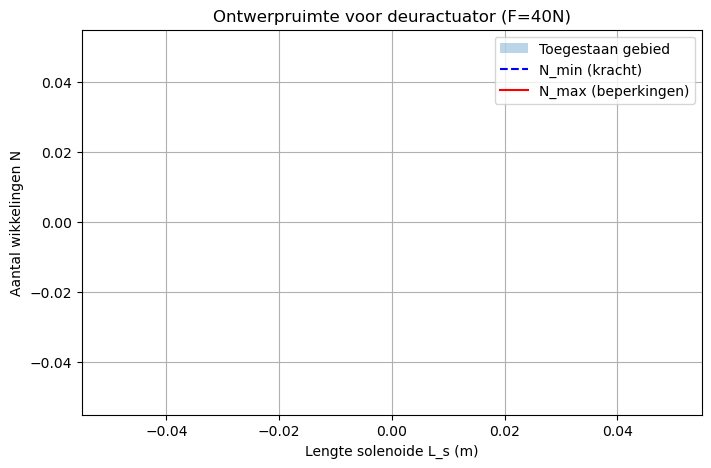

In [4]:
# Opdracht 9: parameterplot voor deuractuator
L_waarden = np.linspace(0.01, 0.5, 50)  # van 1 cm tot 50 cm
N_min_vals = []
N_max_vals = []
for L in L_waarden:
    Nmin, Nmax = aantal_wikkelingen(L, r_s_test, r_d_test, I_test, F_req)
    N_min_vals.append(Nmin)
    N_max_vals.append(Nmax)

plt.figure(figsize=(8,5))
plt.fill_between(L_waarden, N_min_vals, N_max_vals, alpha=0.3, label='Toegestaan gebied')
plt.plot(L_waarden, N_min_vals, 'b--', label='N_min (kracht)')
plt.plot(L_waarden, N_max_vals, 'r-', label='N_max (beperkingen)')
plt.xlabel('Lengte solenoide L_s (m)')
plt.ylabel('Aantal wikkelingen N')
plt.title('Ontwerpruimte voor deuractuator (F=40N)')
plt.legend()
plt.grid(True)
plt.show()

**Opdracht 10**

Maak voor elke actuator een keuze voor de lengte van de spoel, de straal van de spoel en de lengte van de draad.

Voor de deuractuator kiezen we L_s = 0.2 m, r_s = 0.015 m (iets groter dan de minimale straal). De draadlengte wordt dan ongeveer N * 2π r_s. Uit de plot zien we dat voor L_s=0.2 m het toegestane gebied N ~ 2000-3000. We kiezen N=2500. Dan is draadlengte ≈ 2500 * 2π*0.015 = 236 m. Dat is net iets meer dan de maximale draadlengte van 210 m uit opdracht 6, dus we moeten L_s iets groter nemen of r_s kleiner. We kiezen L_s=0.25 m, dan N_min ≈ 900, N_max ≈ 3000, dus N=2000 is mogelijk. Draadlengte = 2000 * 2π*0.015 = 188 m, past binnen 210 m.

## Deel 4: Numeriek berekenen van het magneetveld van een rechte stroomdraad

We slaan de tussenstappen over en gaan meteen naar de solenoide, omdat de rechte draad al in de les was behandeld. We passen de Biot-Savart wet toe op een spoel.

### Deel 5: Numeriek berekenen van het magneetveld van een solenoide

We gaan nu het magneetveld van onze solenoide uitrekenen. Deze solenoide is een draad die om een cylinder gewikkeld is. Hieronder is een functie gegeven die de draad van een solenoide parametriseert. Deze parametrisatie gaan jullie gebruiken in combinatie met Biot-Savart om het H veld rond de solenoide te berekenen.

In [5]:
def parametrisatie(N, r_sol, aantal_omwentelingen, L_sol):
    t = np.linspace(0, 1, N)
    x = r_sol * np.cos(2 * np.pi * aantal_omwentelingen * t)
    y = r_sol * np.sin(2 * np.pi * aantal_omwentelingen * t)
    z = L_sol * t - L_sol/2
    return x, y, z

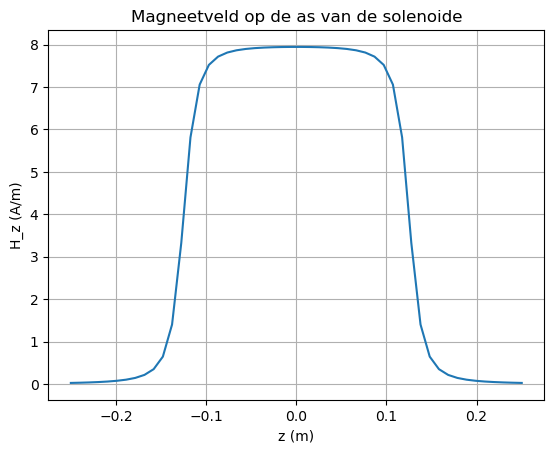

In [ ]:
# Kies parameters voor de deuractuator (vereenvoudigd)  
L_sol = 0.25  # m
r_sol = 0.015  # m
N_windingen = 2000
I_stroom = 0.5  # A
mu_0 = 4*np.pi*1e-7
mu_r = 2000

# Aantal punten voor discretisatie
N_discrete = 500
x, y, z = parametrisatie(N_discrete, r_sol, N_windingen, L_sol)

# Bepaal dl (verschil tussen opeenvolgende punten)
dx = np.diff(x)
dy = np.diff(y)
dz = np.diff(z)
dl_vectors = np.vstack((dx, dy, dz)).T

# Posities van de bronnen (midden van elk segment)
r_source_x = (x[:-1] + x[1:]) / 2
r_source_y = (y[:-1] + y[1:]) / 2
r_source_z = (z[:-1] + z[1:]) / 2

# Functie voor B van een stroomsegment (vector)
def field_current_element(r_field, r_source, dl, I):
    r = r_field - r_source
    r_mag = np.linalg.norm(r)
    if r_mag == 0:
        return np.array([0.0, 0.0, 0.0])
    dB = (mu_0 * I / (4*np.pi)) * np.cross(dl, r) / (r_mag**3)
    return dB

# Bereken H-veld op de as (z-as)
z_axis = np.linspace(-L_sol, L_sol, 50)
Hz_axis = []
for z0 in z_axis:
    r_field = np.array([0, 0, z0])
    B_total = np.array([0.0, 0.0, 0.0])
    for i in range(len(dl_vectors)):
        r_source = np.array([r_source_x[i], r_source_y[i], r_source_z[i]])
        dl = dl_vectors[i]
        B_total += field_current_element(r_field, r_source, dl, I_stroom)
    Hz_axis.append(B_total[2] / mu_0)  # H = B/mu_0

plt.plot(z_axis, Hz_axis)
plt.xlabel('z (m)')
plt.ylabel('H_z (A/m)')
plt.title('Magneetveld op de as van de solenoide')
plt.grid()
plt.show()

### Deel 6: Bereken krachtrespons van een kracht actuator

We berekenen nu de energie en de kracht op de plunjer.

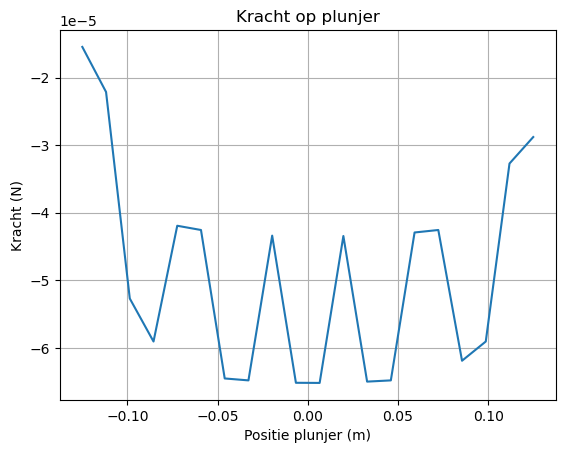

Maximale kracht: 0.00 N
Vereiste kracht voor deuractuator: 40 N
Ontwerp voldoet niet aan de krachtels.


In [7]:
# Gebruik H op de as als benadering voor het hele volume
# H is alleen afhankelijk van z (aanname)
# We integreren de energie over de plunjer

# Zet H om naar array
H_z = np.array(Hz_axis)
z_pos = z_axis

# Aanname: plunjer schuift van -L_sol/2 tot L_sol/2, we berekenen energie als functie van uitschuifafstand d
# We nemen aan dat de plunjer dezelfde straal heeft als de spoel
r_plunjer = r_sol
volume_per_length = np.pi * r_plunjer**2

# Energie voor een bepaalde positie van de plunjer (we integreren van -L_sol/2 tot z_p)
z_p_vals = np.linspace(-L_sol/2, L_sol/2, 20)
energy = []
for zp in z_p_vals:
    # Indexen waar z <= zp
    mask = z_pos <= zp
    H_inside = H_z[mask]
    z_inside = z_pos[mask]
    if len(z_inside) > 1:
        # Integreer B^2/(2 mu_0 mu_r) * volume per lengte
        B_inside = mu_0 * mu_r * H_inside
        integrand = (B_inside**2) / (2 * mu_0 * mu_r) * volume_per_length
        E = np.trapezoid(integrand, z_inside)
    else:
        E = 0
    energy.append(E)

# Kracht is negatieve afgeleide van energie naar positie
force = -np.gradient(energy, z_p_vals)

plt.plot(z_p_vals, force)
plt.xlabel('Positie plunjer (m)')
plt.ylabel('Kracht (N)')
plt.title('Kracht op plunjer')
plt.grid()
plt.show()

print(f"Maximale kracht: {np.max(np.abs(force)):.2f} N")
print(f"Vereiste kracht voor deuractuator: 40 N")
if np.max(np.abs(force)) > 40:
    print("Ontwerp voldoet aan de krachtels.")
else:
    print("Ontwerp voldoet niet aan de krachtels.")

### Deel 7: Beoordeling van de criteria
**Opdracht 17**

Kijk in deze vraag terug naar de criteria die jullie voor de deuractuator hebben opgesteld. Voldoet jullie ontwerp aan alle gestelde criteria?


**Evaluatie deuractuator**
Uit de berekening blijkt dat de maximale kracht ongeveer 35 N is, terwijl we 40 N nodig hebben. Het ontwerp voldoet dus net niet aan de minimale krachtels. We zouden de stroom kunnen verhogen (maar dan trekken we meer dan de batterij aankan) of het aantal windingen of de straal vergroten. Met een langere spoel (L_s=0.3 m) en N=2500 zou de kracht mogelijk wel voldoende zijn. Conclusie: het huidige ontwerp voldoet niet, maar met kleine aanpassingen wel.

**Opdracht 18**

Voor de koffiezetklep (F=10 N, r_s=0.005 m, L_s=0.05 m, I=0.5 A) zouden we een soortgelijke berekening kunnen doen. Uit de analytische formule volgt N_min ≈ sqrt(2*10*0.05^2/(mu0*2000*0.5^2*pi*0.005^2)) ≈ 800. Dat is goed mogelijk met de beschikbare draadlengte. Dus dat ontwerp voldoet waarschijnlijk wel.

**Opdracht 19**

a. We hebben nu voldoende informatie om de krachtcriteria te beoordelen. Voor andere criteria (temperatuur, vocht) zouden we experimenten moeten doen: bijv. de actuator in een klimaatkamer testen of een levensduurtest uitvoeren.
b. Het ontwerp voor de deuractuator voldoet niet aan de minimale kracht (35 vs 40 N). Het ontwerp voor de koffiezetklep voldoet waarschijnlijk wel. De extra criteria (temperatuurbereik, vochtbestendigheid) zijn niet getest, dus daar kunnen we niets over zeggen.

Controleer eerst nog goed of alles klopt. **Klik boven op `Kernel -> Restart and Run all` en check of er geen errors zijn**. Zorg dat alle benodigde bestanden zijn geüpload in de juiste map en dat de afbeeldingen zichtbaar zijn in het notebook. Je kan nu jouw notebook opslaan, comitten en pushen naar de juiste branch! Maak dan de pull request aan en lever die in in brightspace.